# Carga y Proceso de Microdatos: ENARES 2024

Este notebook organiza y procesa los capítulos de la ENARES 2024, de forma independiente.
Las definiciones de variables y tipos se basan en el 'Diccionario de variables' oficial de la ENARES (disponible en la documentación de INEI).

In [1]:
# Cargar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración centralizada de tipos (Basado en el Diccionario de variables ENARES)
# Asegura que las columnas de identificación mantengan ceros a la izquierda, y se conserven todas en cruces y select_dtypes
dtypes_config = {
    'ID': str,
    'CONGLOME': str,
    'NSELV': str,
    'ID_MUESTRA': str,
    'CCDD': str,
    'CCPP': str,
    'CCDI': str,
    'CODCCPP': str,
    'HOGARN': str,
    'HOGAR_ID': str,
    'PERSONA_ID': str,
    'DEPARTAMENTO': str,
    'PROVINCIA': str,
    'DISTRITO': str,
    'NOMCCPP': str,
    'AREA': str,
    'RESVIV': str,
    'RFINAL': str
}

## Carga de Archivos de Datos

In [2]:
# Carga de capítulos activos (OMITIDOS los no relevantes según requerimiento)
crs01_cap100 = pd.read_csv(r'ENARES_2024\CRS01\01_CRS01_CAP100.csv', dtype=dtypes_config)
crs01_cap200 = pd.read_csv(r'ENARES_2024\CRS01\02_CRS01_CAP200.csv', dtype=dtypes_config)
crs01_cap300 = pd.read_csv(r'ENARES_2024\CRS01\03_CRS01_CAP300.csv', dtype=dtypes_config)
crs01_cap400 = pd.read_csv(r'ENARES_2024\CRS01\04_CRS01_CAP400.csv', dtype=dtypes_config)
crs01_cap402 = pd.read_csv(r'ENARES_2024\CRS01\05_CRS01_CAP402.csv', dtype=dtypes_config)
crs01_cap500 = pd.read_csv(r'ENARES_2024\CRS01\08_CRS01_CAP500.csv', dtype=dtypes_config)

In [3]:
# ==============================================================================
# TRANSFORMACIONES GLOBALES PREVIAS A LA SEPARACIÓN POR CAPÍTULOS
# Centralizamos la conversión a dtypes numéricos y la estandarización binomial 
# (Reemplazando 2->0 para respuestas negativas) guiándonos por dtypes_config.
# ==============================================================================

# 1. CONVERSIÓN MASIVA A NUMÉRICO PARA TODAS LAS COLUMNAS DE ENCUESTA
# Excluimos las columnas de dtypes_config (que obligatoriamente son objetos/cadenas para IDs)
llaves_metadatos = set(dtypes_config.keys())
dfs_activos = [crs01_cap100, crs01_cap200, crs01_cap300, crs01_cap400, crs01_cap402, crs01_cap500]

for df in dfs_activos:
    # Seleccionamos todas las columnas que NO son metadatos/llaves compartidas
    cols_encuesta = [c for c in df.columns if c not in llaves_metadatos]
    for col in cols_encuesta:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. ESTANDARIZACIÓN BINARIA (Modificando 2 = 'No' a 0, y llenando vacíos con 0)
# CAP 100: Bienes
columnas_bienes = [col for col in crs01_cap100.columns if col.startswith('C1P110_')]
crs01_cap100[columnas_bienes] = crs01_cap100[columnas_bienes].replace({2: 0, 2.0: 0}).fillna(0).astype(int)

# CAP 300: Programas Sociales, Ocupación y Estado Civil
mapping_programas = {
    'C1P315_1': 'JUNTOS', 'C1P315_2': 'Vaso de Leche/Comedor', 'C1P315_3': 'Qali Warma/Cuna Más',
    'C1P315_4': 'Pensión 65', 'C1P315_4_1': 'Beca 18', 'C1P315_5': 'Otros'
}
cols_programas = list(mapping_programas.keys())

for col in cols_programas:
    crs01_cap300[col] = crs01_cap300[col].replace({2: 0, 2.0: 0}).fillna(0).astype(int)

# CAP 400: Violencia en la niñez
cols_violencia_ninez = [f'CAP441A_{i}' for i in range(1, 7)]
for col in cols_violencia_ninez:
    crs01_cap400[col] = crs01_cap400[col].replace({2: 0, 2.0: 0}).fillna(0).astype(int)

# CAP 402: Violencia a la Mujer (Distintos frentes: Control, Física, Económica)
cols_control = [f'C1P402_{i}' for i in range(1, 21)]
cols_violencia = [f'C1P404_{i}' for i in range(1, 16)]
cols_violencia_ec = [f'C1P403_{i}' for i in range(1, 8)]
todas_las_columnas_402 = cols_control + cols_violencia + cols_violencia_ec

for col in todas_las_columnas_402:
    crs01_cap402[col] = crs01_cap402[col].replace({2: 0, 2.0: 0}).fillna(0).astype(int)

# 3. VERIFICACIÓN DE DTYPES
print("Verificación de tipo de columnas (metadatos en crs01_cap100):")
print(crs01_cap100[list(llaves_metadatos.intersection(crs01_cap100.columns))].dtypes)

Verificación de tipo de columnas (metadatos en crs01_cap100):
CODCCPP         str
CCPP            str
NSELV           str
RESVIV          str
DISTRITO        str
DEPARTAMENTO    str
AREA            str
ID              str
NOMCCPP         str
ID_MUESTRA      str
HOGAR_ID        str
RFINAL          str
CCDD            str
PROVINCIA       str
CONGLOME        str
HOGARN          str
CCDI            str
dtype: object


In [4]:
crs01_cap500.shape



(13826, 97)

## Capítulo 100: Características de la vivienda y del hogar

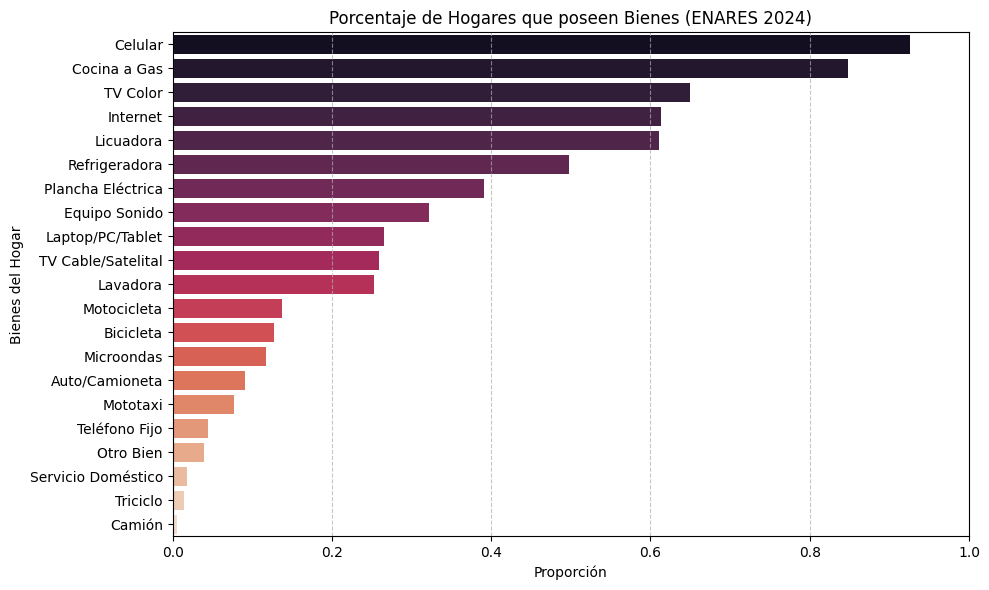

In [7]:
# Mapeo y Visualización de Bienes
mapping_bienes = {
    'C1P110_1': 'Refrigeradora', 'C1P110_2': 'Lavadora', 'C1P110_3': 'Laptop/PC/Tablet',
    'C1P110_4': 'Internet', 'C1P110_5': 'TV Cable/Satelital', 'C1P110_6': 'Teléfono Fijo',
    'C1P110_7': 'Celular', 'C1P110_8': 'Microondas', 'C1P110_9': 'Servicio Doméstico',
    'C1P110_10': 'Equipo Sonido', 'C1P110_11': 'TV Color', 'C1P110_12': 'Cocina a Gas',
    'C1P110_13': 'Licuadora', 'C1P110_14': 'Plancha Eléctrica', 'C1P110_15': 'Auto/Camioneta',
    'C1P110_16': 'Bicicleta', 'C1P110_17': 'Motocicleta', 'C1P110_18': 'Triciclo',
    'C1P110_19': 'Mototaxi', 'C1P110_20': 'Camión', 'C1P110_21': 'Otro Bien'
}

stats_bienes = crs01_cap100[columnas_bienes].mean().rename(mapping_bienes).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=stats_bienes.values, y=stats_bienes.index, hue=stats_bienes.index, palette='rocket', legend=False)
plt.title('Porcentaje de Hogares que poseen Bienes (ENARES 2024)')
plt.xlabel('Proporción')
plt.ylabel('Bienes del Hogar')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

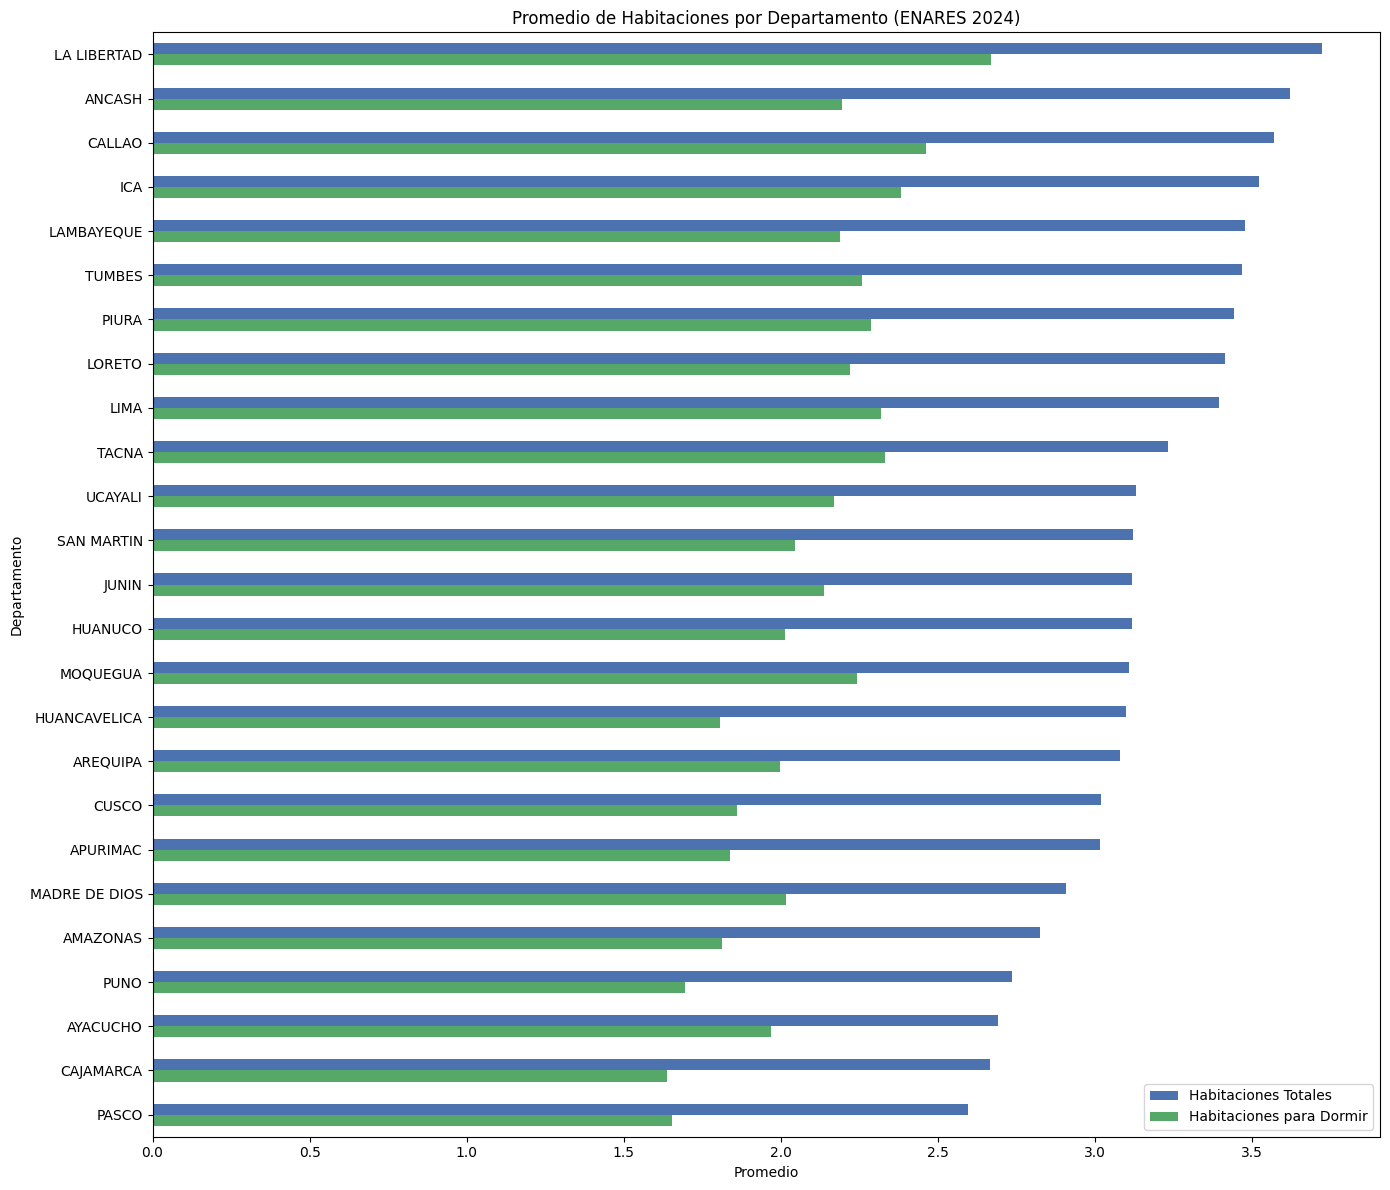

In [17]:
# Calcular promedios, renombrar columnas y ordenar en una secuencia más directa
dfc = crs01_cap100.groupby('DEPARTAMENTO')[['C1P108', 'C1P109']].mean()
dfc.columns = ['Habitaciones Totales', 'Habitaciones para Dormir']
dfc = dfc.sort_values(by='Habitaciones Totales', ascending=False)

# Gráfico de barras agrupadas (horizontal) por departamento
ax = dfc.plot(kind='barh', figsize=(14, 12), color=['#4C72B0', '#55A868'])
ax.set_xlabel('Promedio')
ax.set_ylabel('Departamento')
ax.set_title('Promedio de Habitaciones por Departamento (ENARES 2024)')
ax.invert_yaxis()  # mantener el mismo orden visual (mayor arriba)
plt.legend(title='')
plt.tight_layout()
plt.show()


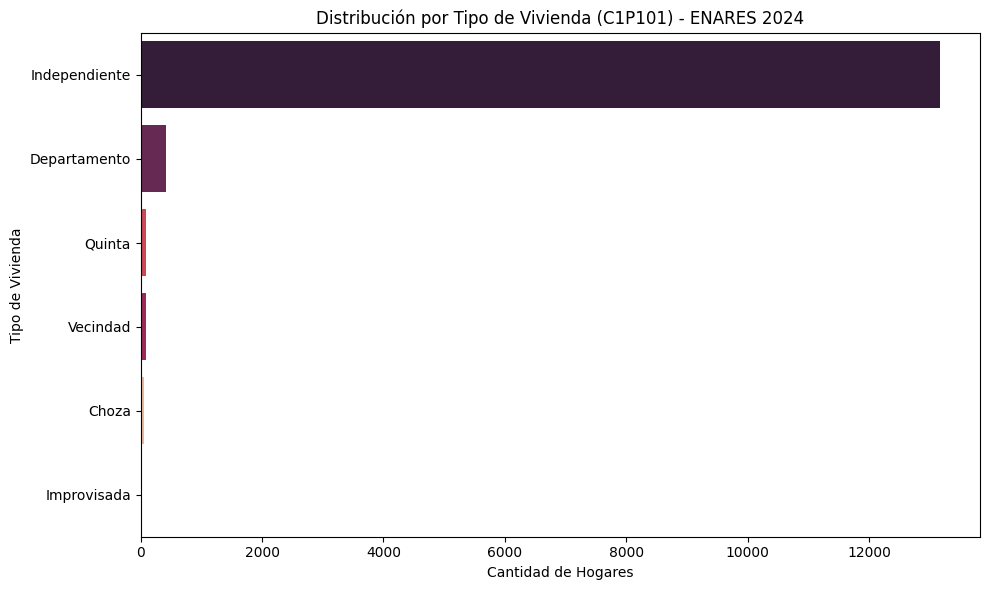

In [18]:
# Visualización Tipo de Vivienda y Mapeo en el gráfico
map_vivienda = {1: "Independiente", 2: "Departamento", 3: "Quinta", 4: "Vecindad", 5: "Choza", 6: "Improvisada", 7: "Local", 8: "Otro"}

plt.figure(figsize=(10, 6))
# Se usa map solo para la visualización, no se modifica crs01_cap100
sns.countplot(y=crs01_cap100['C1P101'].map(map_vivienda), order=crs01_cap100['C1P101'].map(map_vivienda).value_counts().index, palette="rocket", hue=crs01_cap100['C1P101'].map(map_vivienda), legend=False)
plt.title('Distribución por Tipo de Vivienda (C1P101) - ENARES 2024')
plt.xlabel('Cantidad de Hogares')
plt.ylabel('Tipo de Vivienda')
plt.tight_layout()
plt.show()

### 📝 Resumen: Capítulo 100 (Características de la Vivienda y del Hogar)
**Descripción:**  
Este apartado dimensiona las condiciones de habitabilidad de los encuestados, evaluando la penetración de bienes y servicios (desde celulares hasta automóviles), el posible hacinamiento (comparando habitaciones totales vs. exclusivas para dormir) y el tipo predominante de vivienda.

**Estadísticos e insights adicionales relevantes:**
- **Hacinamiento a nivel nacional:** La brecha entre el promedio general de habitaciones y las habitaciones exclusivas para dormir es un indicador clave de calidad de vida. 
- **Bienes más comunes:** Típicamente, el celular de uso personal y acceso a internet son los servicios de mayor tenencia, desplazando al teléfono fijo en años recientes.
- **Predominancia de vivienda:** Una amplia mayoría nacional reside en casas independientes, variando ligeramente solo en áreas altamente urbanizadas donde proliferan los departamentos.

In [19]:
# Generar DataFrame Resumen del CAP 100
# Incluye variables no numéricas (IDs como str, categóricas) y numéricas utilizadas en visualizaciones
cols_numericas_graficadas_100 = columnas_bienes + ['C1P108', 'C1P109', 'C1P101']
cols_no_numericas_100 = crs01_cap100.select_dtypes(exclude=[np.number]).columns.tolist()

df_cap100_resumen = crs01_cap100[cols_no_numericas_100 + cols_numericas_graficadas_100].copy()

## Capítulo 200: Características de los miembros del hogar

In [20]:
# Preparamos dataframe de trabajo sin nans pre-existentes para visualizado limpio
df_clean_200 = crs01_cap200.dropna(subset=['C1P210']).copy()
df_clean_200['C1P210'] = df_clean_200['C1P210'].astype(int)

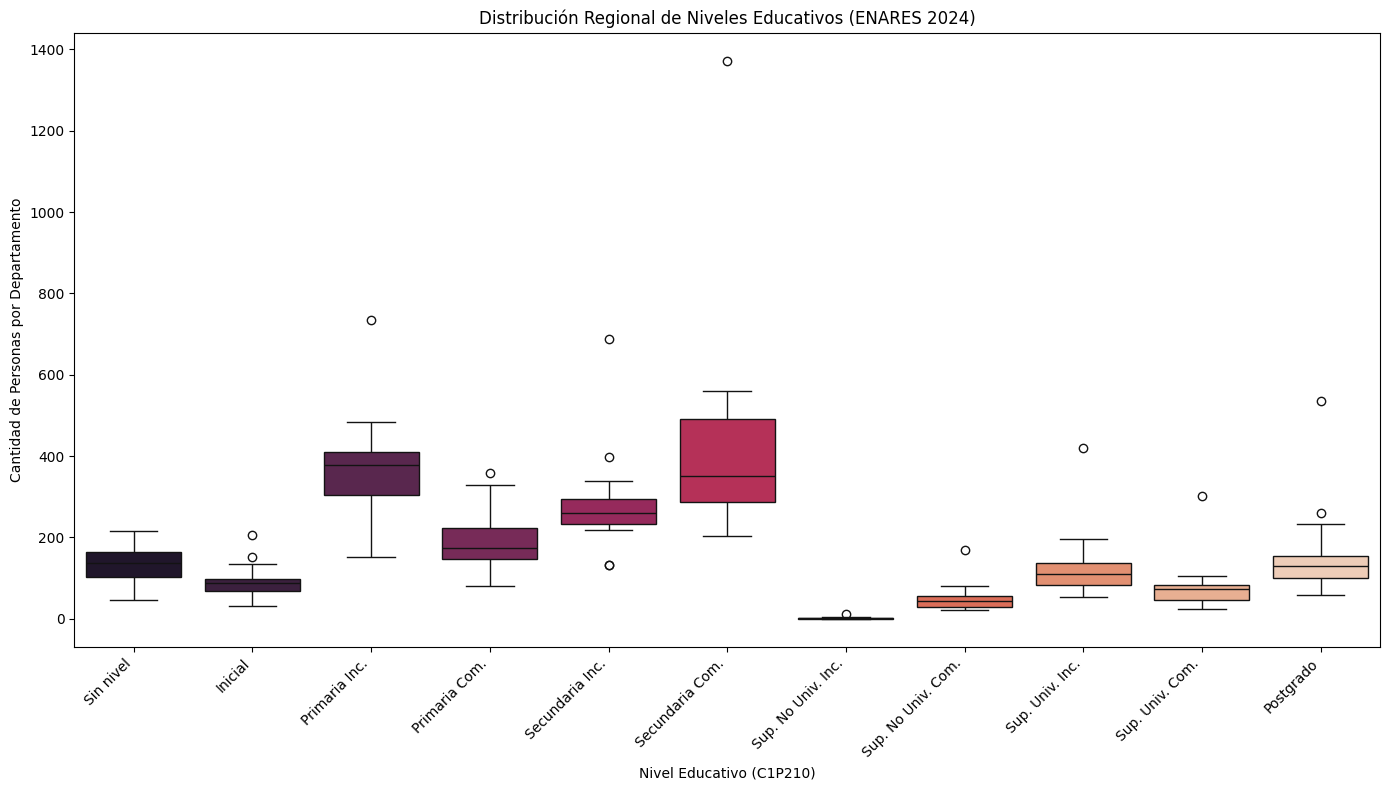

In [21]:
# Mapeo y Visualización de Educación
mapping_educacion = {
    1: "Sin nivel", 2: "Inicial", 3: "Primaria Inc.", 4: "Primaria Com.",
    5: "Secundaria Inc.", 6: "Secundaria Com.", 7: "Sup. No Univ. Inc.",
    8: "Sup. No Univ. Com.", 9: "Sup. Univ. Inc.", 10: "Sup. Univ. Com.", 11: "Postgrado"
}

conteo_matrix = df_clean_200.groupby(['DEPARTAMENTO', 'C1P210']).size().unstack(fill_value=0)
conteo_educativo = conteo_matrix.stack().reset_index(name='Conteo')
conteo_educativo['Nivel_Etiqueta'] = conteo_educativo['C1P210'].map(mapping_educacion)

niveles_validos = conteo_educativo.groupby('Nivel_Etiqueta')['Conteo'].sum()
niveles_validos = niveles_validos[niveles_validos > 0].index.tolist()
orden_logico = [mapping_educacion[k] for k in sorted(mapping_educacion.keys()) if mapping_educacion[k] in niveles_validos]

plt.figure(figsize=(14, 8))
df_final_200 = conteo_educativo[conteo_educativo['Nivel_Etiqueta'].isin(orden_logico)]
sns.boxplot(data=df_final_200, x='Nivel_Etiqueta', y='Conteo', order=orden_logico, palette='rocket', hue='Nivel_Etiqueta', legend=False)
#sns.stripplot(data=df_final_200, x='Nivel_Etiqueta', y='Conteo', order=orden_logico, color='black', alpha=0.3, jitter=True)
plt.title('Distribución Regional de Niveles Educativos (ENARES 2024)')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Nivel Educativo (C1P210)')
plt.ylabel('Cantidad de Personas por Departamento')
plt.tight_layout()
plt.show()

### 📝 Resumen: Capítulo 200 (Características de los Miembros del Hogar)
**Descripción:**  
Este módulo desglosa el estatus de cualificación de la población analizada a nivel departamental, midiendo cómo se dispersa el nivel educativo de las personas desde quienes no cuentan con formación formal hasta estudiantes de posgrado.

**Estadísticas relevantes:**
- **Nivel de formación predominante:** Por lo generar en poblaciones adultas de la ENARES, se observa un gran volumen concentrado en secundaria completa, seguida de primaria.

In [22]:
# Generar DataFrame Resumen del CAP 200
cols_numericas_graficadas_200 = ['C1P210']
cols_no_numericas_200 = crs01_cap200.select_dtypes(exclude=[np.number]).columns.tolist()

df_cap200_resumen = crs01_cap200[cols_no_numericas_200 + cols_numericas_graficadas_200].copy()

## Capítulo 300: Empleo e Ingresos

In [23]:
# Preparamos dataframes de trabajo filtrando ausentes de ocupación y estado civil
df_plot_300 = crs01_cap300.dropna(subset=['C1P309', 'DEPARTAMENTO']).copy()
df_plot_ec = crs01_cap300.dropna(subset=['C1P302', 'DEPARTAMENTO']).copy()

C:\Users\tirad\AppData\Local\Temp\ipykernel_21072\137932193.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_perc = ct.div(ct.sum(1), axis=0) * 100


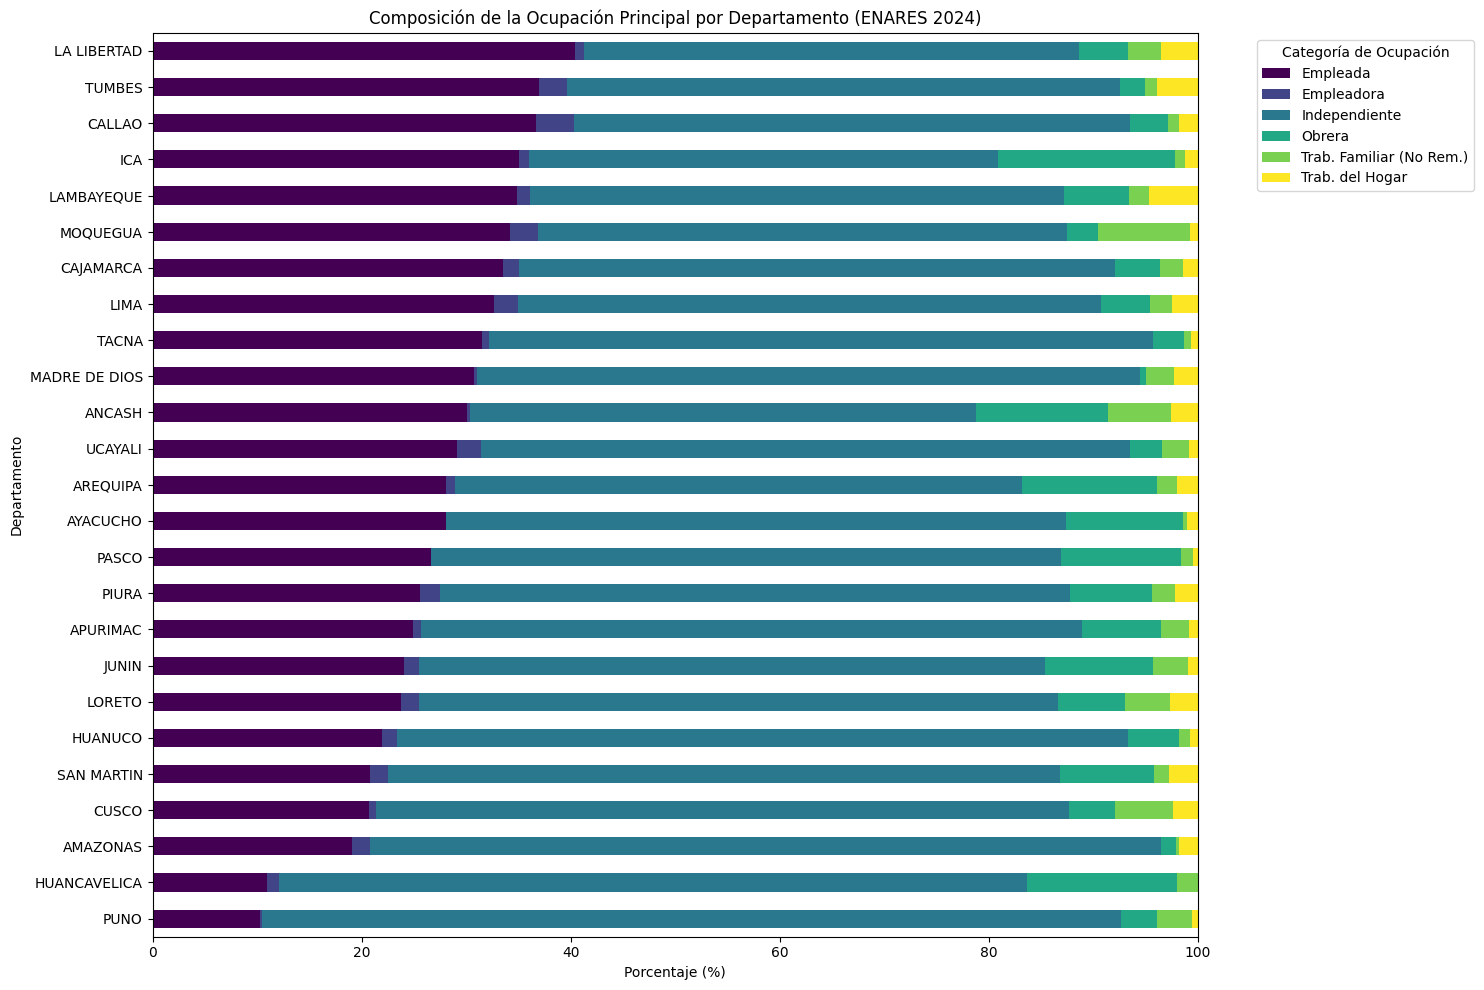

In [31]:
# Mapeo y Visualización de Ocupación
mapping_ocupacion = {1: 'Empleadora', 2: 'Independiente', 3: 'Empleada', 7: 'Obrera', 4: 'Trab. Familiar (No Rem.)', 5: 'Trab. del Hogar', 6: 'Otro'}
df_plot_300['Ocupacion'] = df_plot_300['C1P309'].map(mapping_ocupacion)

ct = pd.crosstab(df_plot_300['DEPARTAMENTO'], df_plot_300['Ocupacion'])
ct_perc = ct.div(ct.sum(1), axis=0) * 100
ct_perc = ct_perc.sort_values(by='Empleada', ascending=True)

ax = ct_perc.plot(kind='barh', stacked=True, figsize=(15, 10), colormap='viridis')
plt.title('Composición de la Ocupación Principal por Departamento (ENARES 2024)')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Departamento')
plt.legend(title='Categoría de Ocupación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

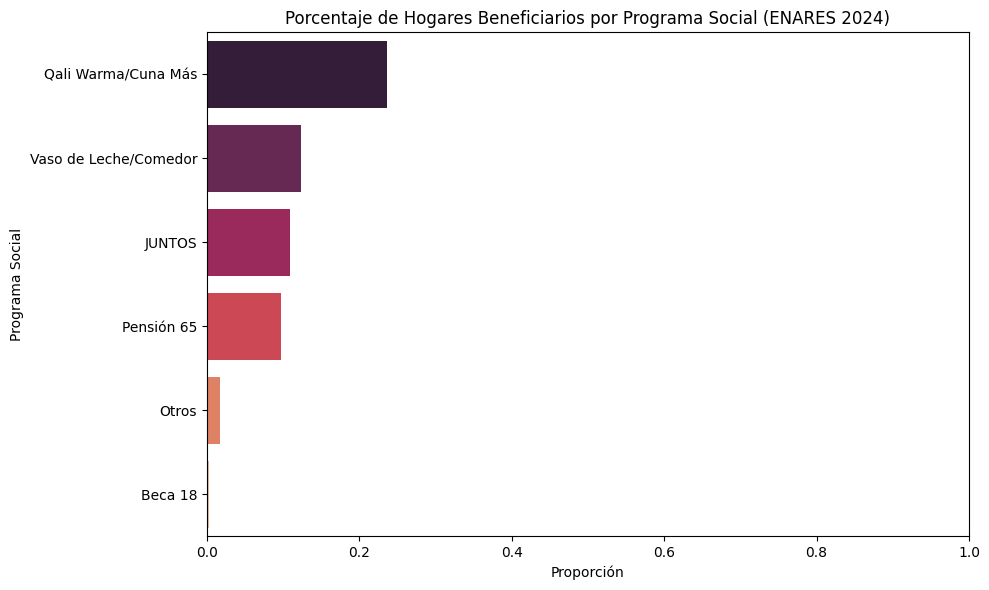

In [25]:
# Mapeo y Visualización de Programas Sociales
proporciones = crs01_cap300[cols_programas].mean().sort_values(ascending=False)
proporciones.index = [mapping_programas[idx] for idx in proporciones.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=proporciones.values, y=proporciones.index, palette='rocket', hue=proporciones.index, legend=False)
plt.title('Porcentaje de Hogares Beneficiarios por Programa Social (ENARES 2024)')
plt.xlabel('Proporción')
plt.ylabel('Programa Social')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

C:\Users\tirad\AppData\Local\Temp\ipykernel_21072\2032959623.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_perc_ec = ct_ec.div(ct_ec.sum(1), axis=0) * 100


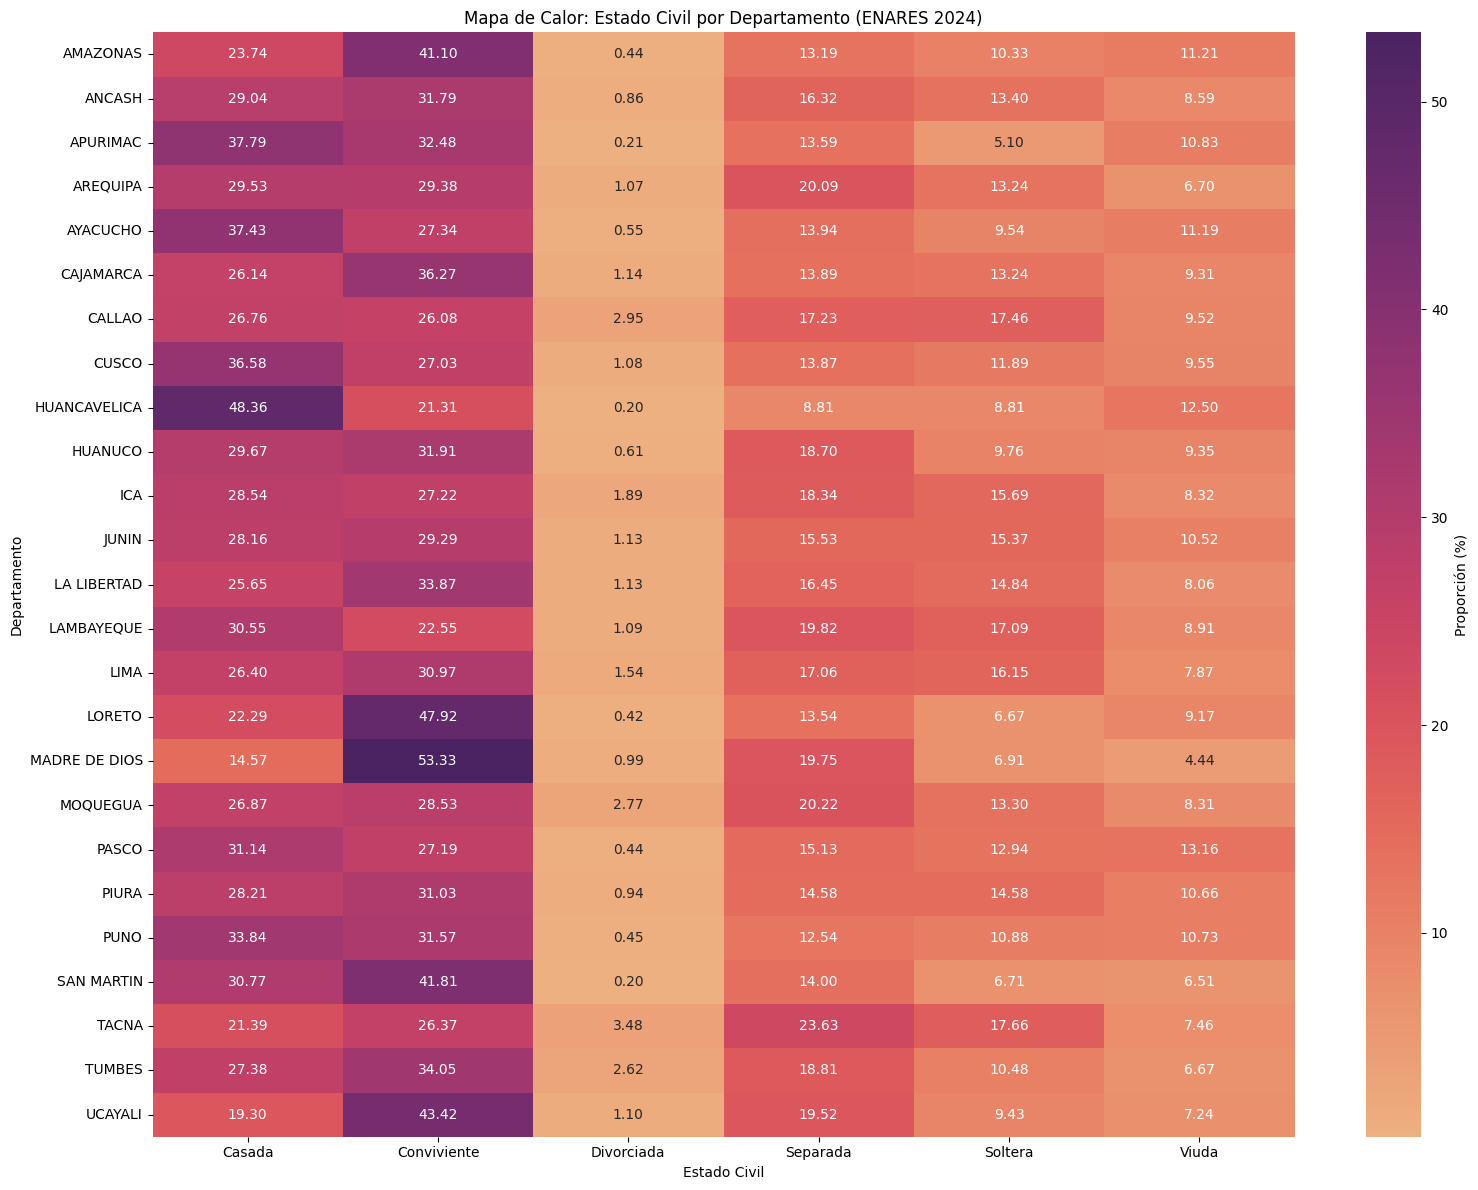

In [29]:
# Mapeo y Visualización de Estado Civil
mapping_estado_civil = {1: 'Conviviente', 2: 'Casada', 3: 'Viuda', 4: 'Divorciada', 5: 'Separada', 6: 'Soltera'}
df_plot_ec['Estado Civil'] = df_plot_ec['C1P302'].map(mapping_estado_civil)

ct_ec = pd.crosstab(df_plot_ec['DEPARTAMENTO'], df_plot_ec['Estado Civil'])
ct_perc_ec = ct_ec.div(ct_ec.sum(1), axis=0) * 100

plt.figure(figsize=(16, 12))
sns.heatmap(ct_perc_ec, annot=True, fmt=".2f", cmap="flare", cbar_kws={'label': 'Proporción (%)'})
plt.title('Mapa de Calor: Estado Civil por Departamento (ENARES 2024)')
plt.xlabel('Estado Civil')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

### 📝 Resumen: Capítulo 300 (Empleo e Ingresos)
**Descripción:**  
Este capítulo aborda la situación económica y socio-familiar, mapeando las fuentes de trabajo principal, estado civil, y el grado de penetración de programas sociales de asistencia gubernamental como Qali Warma, Juntos o Pensión 65.

**Estadísticos e insights adicionales relevantes:**
- **Prevalencia del trabajo independiente y doméstico:** Destaca un porcentaje alto de población que labora independientemente o que dedica gran parte de su tiempo a trabajo familiar/doméstico sin remuneración monetaria. 
- **Estatus marital:** Usualmente el estado civil de Casada o Conviviente absorbe gran sector debido a la constitución estándar de la unidad de análisis de mujeres en ENARES.
- **Cobertura estatal:** Qali Warma/Cuna Más y Vaso de Leche/Comedor son los servicios predominantes de ayuda social al que acceden las mujeres de la muestra.

In [125]:
# Generar DataFrame Resumen del CAP 300
cols_numericas_graficadas_300 = ['C1P309', 'C1P302'] + list(mapping_programas.keys())
cols_no_numericas_300 = crs01_cap300.select_dtypes(exclude=[np.number]).columns.tolist()

df_cap300_resumen = crs01_cap300[cols_no_numericas_300 + cols_numericas_graficadas_300].copy()

## Capítulo 400: Violencia en la niñez

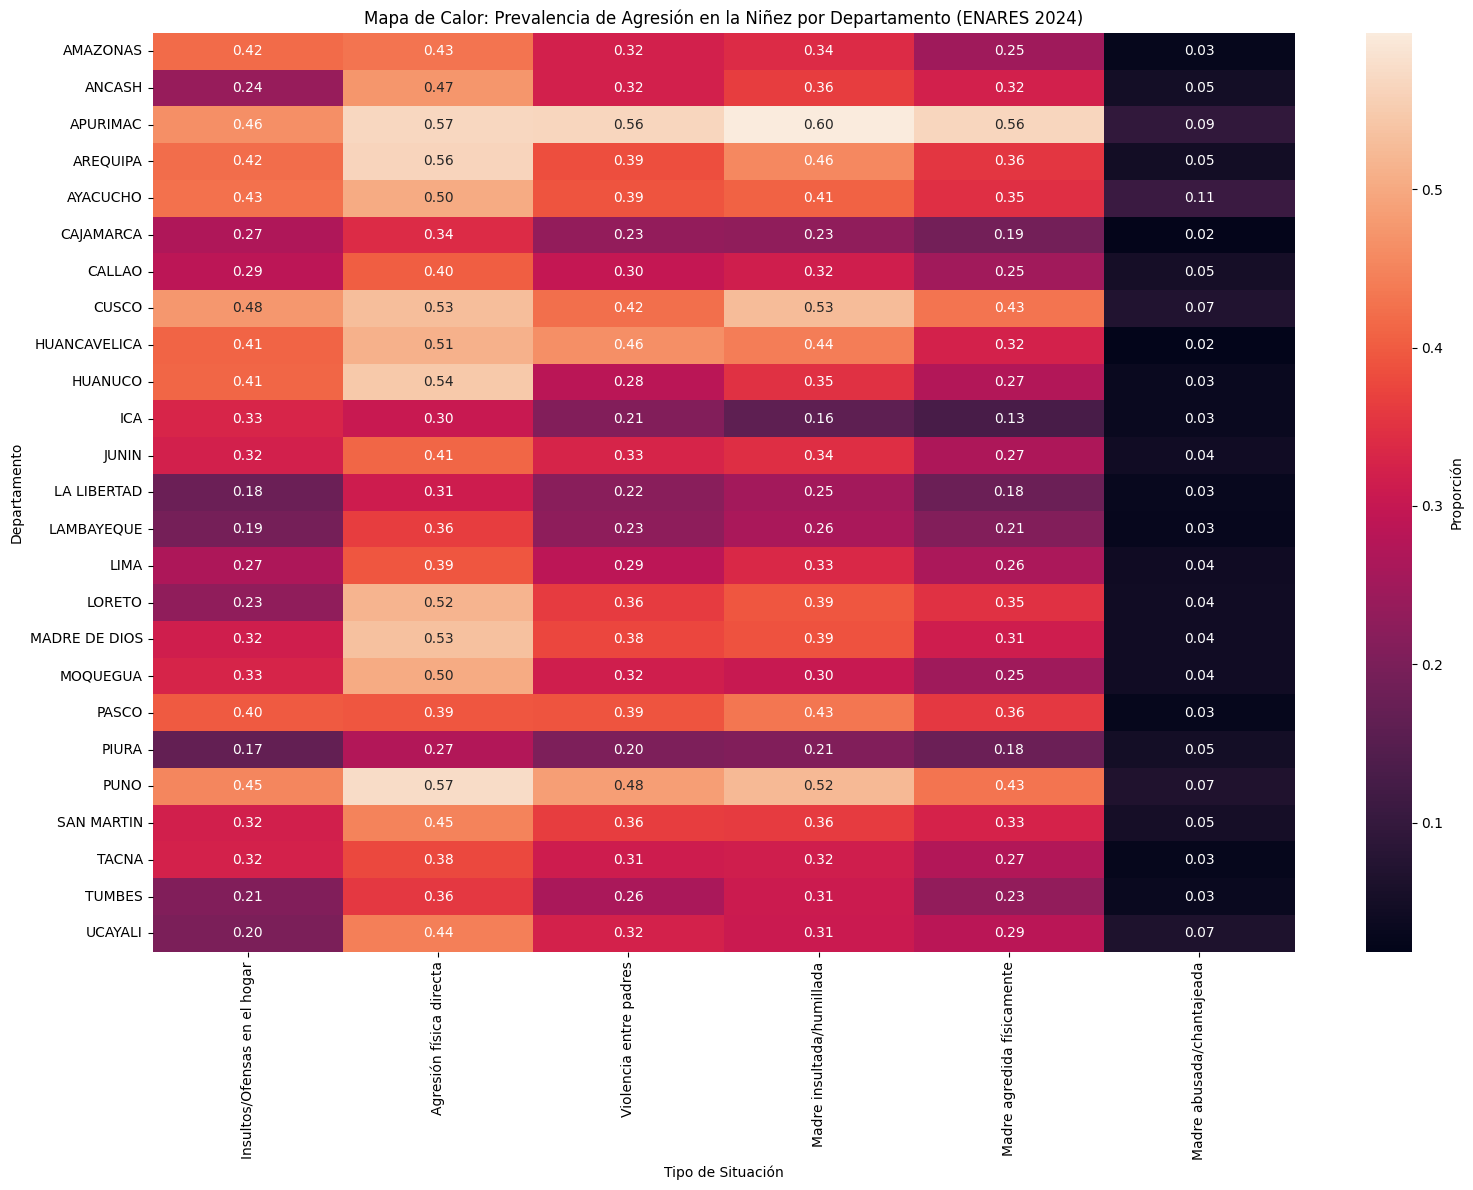

In [140]:
# Mapeo y Visualización de Violencia en Niñez
mapping_violencia_ninez = {
    'CAP441A_1': 'Insultos/Ofensas en el hogar', 'CAP441A_2': 'Agresión física directa',
    'CAP441A_3': 'Violencia entre padres', 'CAP441A_4': 'Madre insultada/humillada',
    'CAP441A_5': 'Madre agredida físicamente', 'CAP441A_6': 'Madre abusada/chantajeada'
}

df_heatmap_ninez = crs01_cap400.groupby('DEPARTAMENTO')[cols_violencia_ninez].mean()
df_heatmap_ninez.columns = [mapping_violencia_ninez[col] for col in df_heatmap_ninez.columns]

plt.figure(figsize=(16, 12))
sns.heatmap(df_heatmap_ninez, annot=True, fmt=".2f", cmap="rocket", cbar_kws={'label': 'Proporción'})
plt.title('Mapa de Calor: Prevalencia de Agresión en la Niñez por Departamento (ENARES 2024)')
plt.xlabel('Tipo de Situación')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

### 📝 Resumen: Capítulo 400 (Violencia en la Niñez)
**Descripción:**  
Refleja la experiencia retrospectiva y exposición directa de la encuestada a diversas tipologías de agresión infantil y adolescencia en su ámbito de contención inicial (hogar).

**Estadísticos e insights adicionales relevantes:**
- **Transmisión intergeneracional:** Las variables analizan insultos o violencia presenciada entre los progenitores lo cual suele asociarse posteriormente con la normalización de castigos en el hogar derivado.
- **Tipología agresiva dominante:** Los estudios consistentemente señalan la agresión verbal o castigo corporal directo como la forma de corrección parento-filial más declarada, con incidencias regionales variables.

In [127]:
# Generar DataFrame Resumen del CAP 400
cols_numericas_graficadas_400 = cols_violencia_ninez
cols_no_numericas_400 = crs01_cap400.select_dtypes(exclude=[np.number]).columns.tolist()

df_cap400_resumen = crs01_cap400[cols_no_numericas_400 + cols_numericas_graficadas_400].copy()

## Capítulo 402: Violencia a la Mujer por parte del Esposo/Pareja

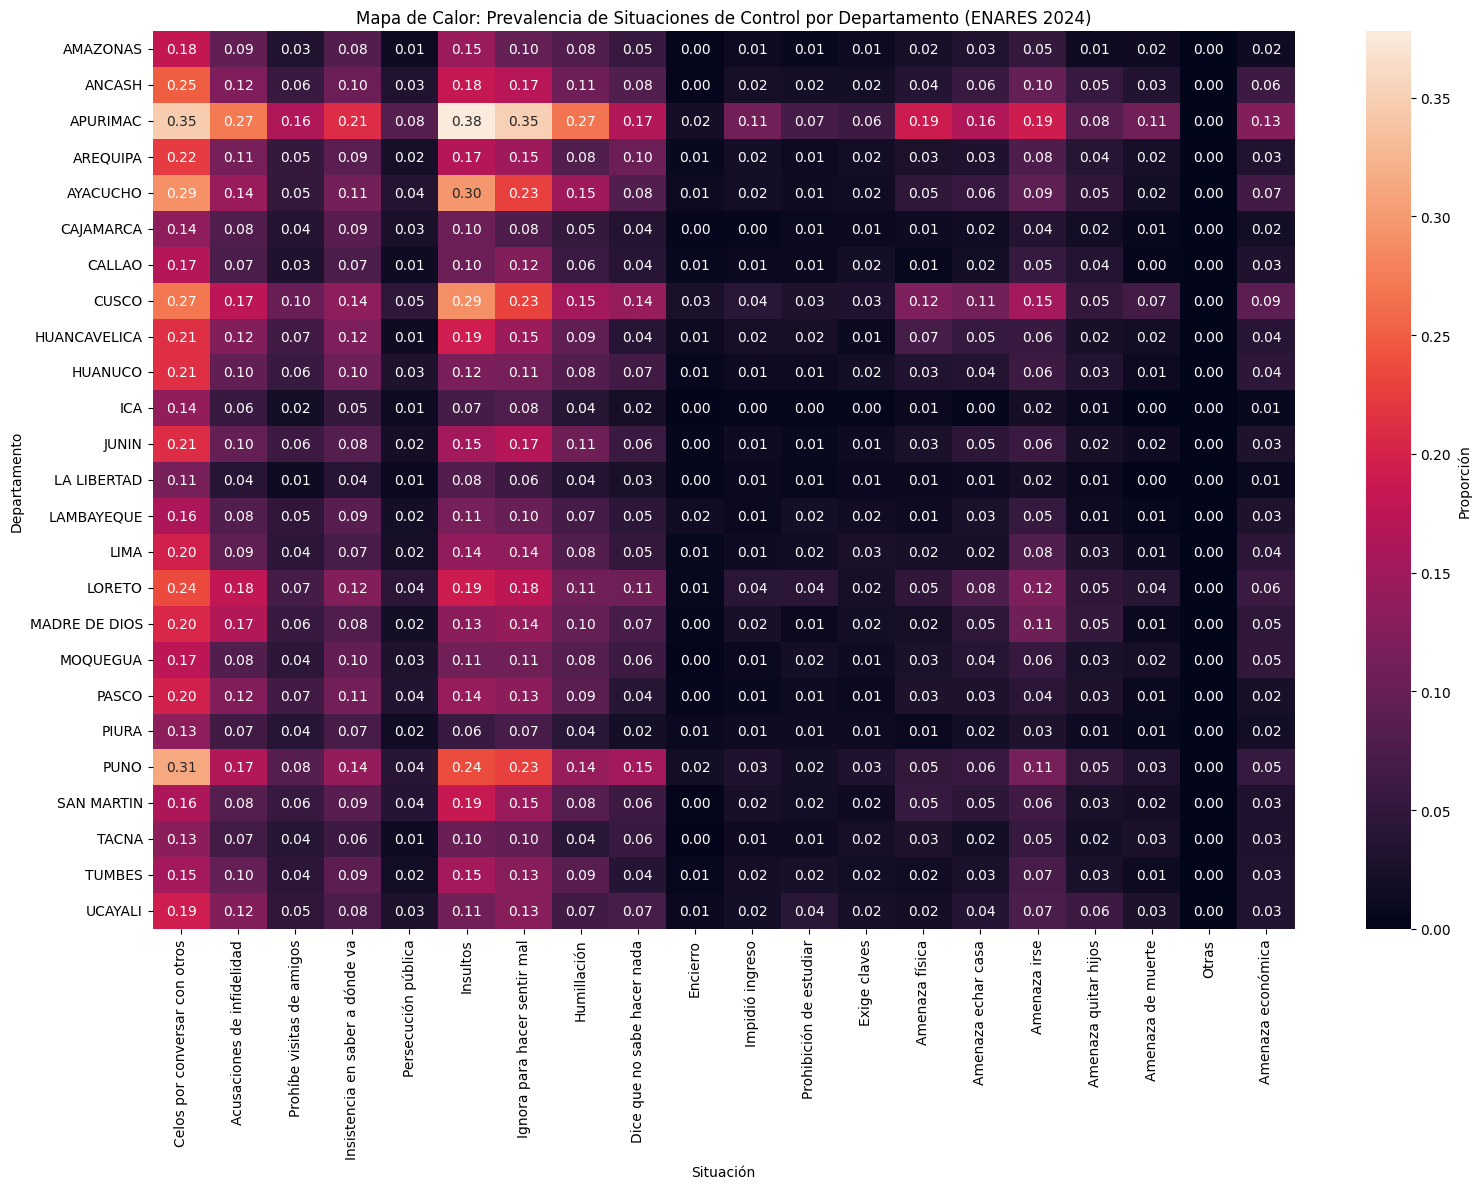

In [141]:
# Mapeo y visualización Control
mapping_control = {
    'C1P402_1': 'Celos por conversar con otros', 'C1P402_2': 'Acusaciones de infidelidad',
    'C1P402_3': 'Prohíbe visitas de amigos', 'C1P402_4': 'Insistencia en saber a dónde va',
    'C1P402_5': 'Persecución pública', 'C1P402_6': 'Insultos', 'C1P402_7': 'Ignora para hacer sentir mal',
    'C1P402_8': 'Humillación', 'C1P402_9': 'Dice que no sabe hacer nada', 'C1P402_10': 'Encierro',
    'C1P402_11': 'Impidió ingreso', 'C1P402_12': 'Prohibición de estudiar', 'C1P402_13': 'Exige claves',
    'C1P402_14': 'Amenaza física', 'C1P402_15': 'Amenaza echar casa', 'C1P402_16': 'Amenaza irse',
    'C1P402_17': 'Amenaza quitar hijos', 'C1P402_18': 'Amenaza de muerte', 'C1P402_19': 'Otras',
    'C1P402_20': 'Amenaza económica'
}

df_heatmap_control = crs01_cap402.groupby('DEPARTAMENTO')[cols_control].mean()
df_heatmap_control.columns = [mapping_control[col] for col in df_heatmap_control.columns]

plt.figure(figsize=(16, 12))
sns.heatmap(df_heatmap_control, annot=True, fmt=".2f", cmap="rocket", cbar_kws={'label': 'Proporción'})
plt.title('Mapa de Calor: Prevalencia de Situaciones de Control por Departamento (ENARES 2024)')
plt.xlabel('Situación')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

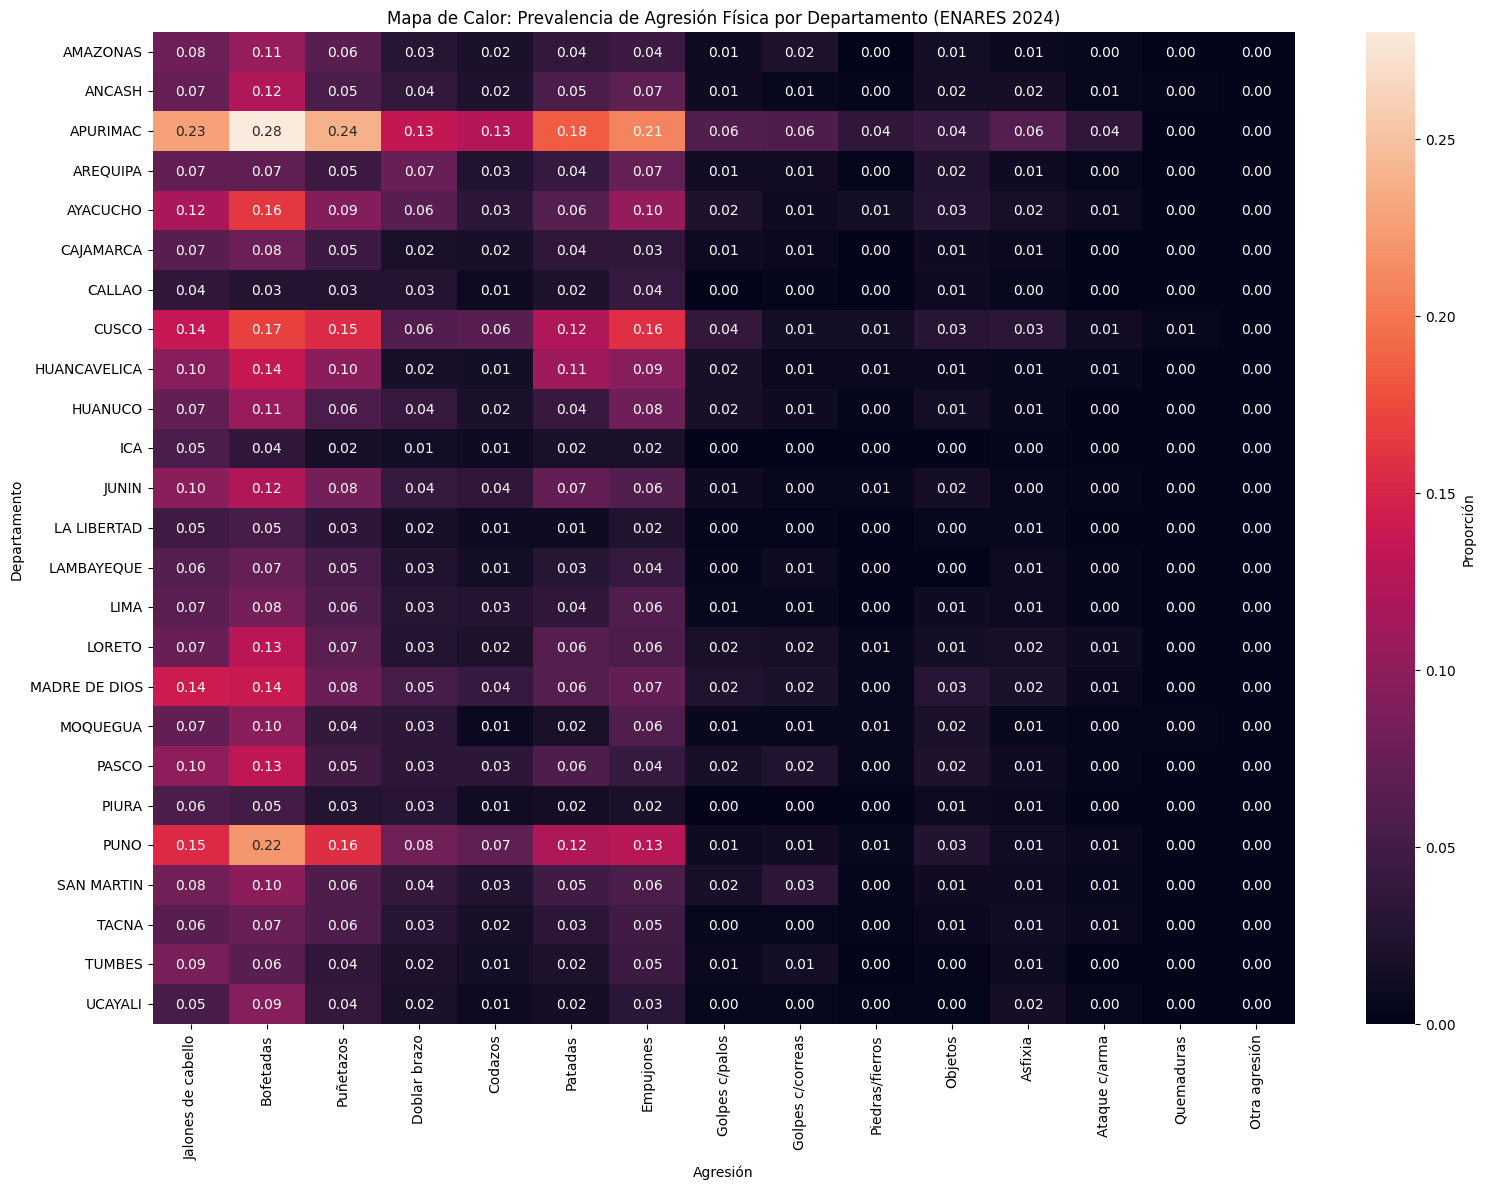

In [142]:
# Mapeo y Visualización Violencia Física
mapping_agresion = {
    'C1P404_1': 'Jalones de cabello', 'C1P404_2': 'Bofetadas', 'C1P404_3': 'Puñetazos',
    'C1P404_4': 'Doblar brazo', 'C1P404_5': 'Codazos', 'C1P404_6': 'Patadas', 'C1P404_7': 'Empujones',
    'C1P404_8': 'Golpes c/palos', 'C1P404_9': 'Golpes c/correas', 'C1P404_10': 'Piedras/fierros',
    'C1P404_11': 'Objetos', 'C1P404_12': 'Asfixia', 'C1P404_13': 'Ataque c/arma', 'C1P404_14': 'Quemaduras',
    'C1P404_15': 'Otra agresión'
}
df_heatmap_agresion = crs01_cap402.groupby('DEPARTAMENTO')[cols_violencia].mean()
df_heatmap_agresion.columns = [mapping_agresion.get(col, col) for col in df_heatmap_agresion.columns]

plt.figure(figsize=(16, 12))
sns.heatmap(df_heatmap_agresion, annot=True, fmt=".2f", cmap="rocket", cbar_kws={'label': 'Proporción'})
plt.title('Mapa de Calor: Prevalencia de Agresión Física por Departamento (ENARES 2024)')
plt.xlabel('Agresión')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

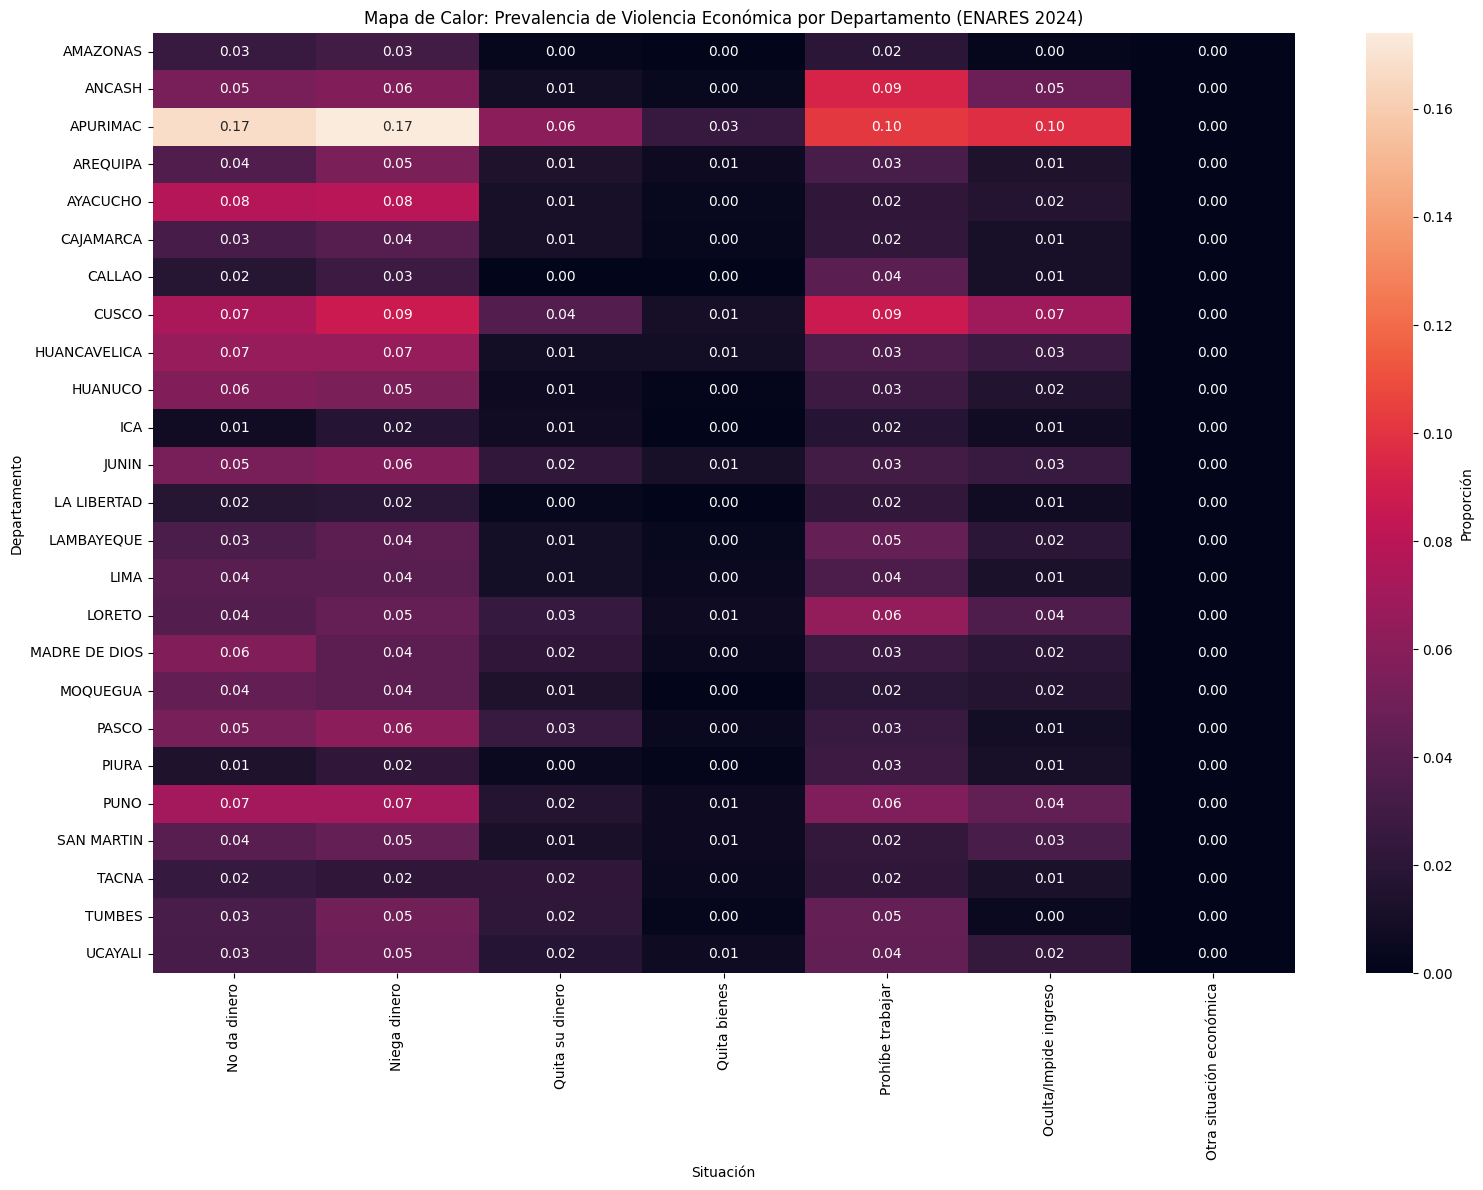

In [143]:
# Mapeo y Visualización Violencia Económica
mapping_ec = {
    'C1P403_1': 'No da dinero', 'C1P403_2': 'Niega dinero', 'C1P403_3': 'Quita su dinero',
    'C1P403_4': 'Quita bienes', 'C1P403_5': 'Prohíbe trabajar', 'C1P403_6': 'Oculta/Impide ingreso',
    'C1P403_7': 'Otra situación económica'
}
df_heatmap_ec = crs01_cap402.groupby('DEPARTAMENTO')[cols_violencia_ec].mean()
df_heatmap_ec.columns = [mapping_ec.get(col, col) for col in df_heatmap_ec.columns]

plt.figure(figsize=(16, 12))
sns.heatmap(df_heatmap_ec, annot=True, fmt=".2f", cmap="rocket", cbar_kws={'label': 'Proporción'})
plt.title('Mapa de Calor: Prevalencia de Violencia Económica por Departamento (ENARES 2024)')
plt.xlabel('Situación')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

### 📝 Resumen: Capítulo 402 (Violencia a la Mujer por parte de la Pareja/Esposo)
**Descripción:**  
Es uno de los capítulos centrales de interés, centrado en medir, de forma pormenorizada, tres grandes categorías de abuso contra la mujer en sus relaciones de intimidad: control coercitivo, violencia física explícita, y retención o abuso económico.

**Estadísticos e insights adicionales relevantes:**
- **Invisibilidad del Control:** Las métricas relacionadas a control (revisión de celular, sospechas de salidas, limitación externa, celos) presentan históricamente prevalencias porcentuales mucho más abultadas y normalizadas.
- **Gradientes de violencia explícita:** La violencia física suele representar a una población minoritaria comparada a casos de agresión verbal/coerción, escalando gravemente desde jalones/empujones hasta agresiones por asfixia en el estrato más extremo.

In [131]:
# Generar DataFrame Resumen del CAP 402
cols_numericas_graficadas_402 = todas_las_columnas_402
cols_no_numericas_402 = crs01_cap402.select_dtypes(exclude=[np.number]).columns.tolist()

df_cap402_resumen = crs01_cap402[cols_no_numericas_402 + cols_numericas_graficadas_402].copy()

## Consolidación y Unión de los DataFrames (Merged)

In [132]:
# Consolidación de DataFrames a nivel Persona
# La clave a nivel hogar es: CONGLOME, NSELV, HOGAR_ID
# La clave a nivel persona (al haber añadido a dtypes_config 'PERSONA_ID' todo cruza limpio) 

# La llave robusta provista por ENARES es HOGAR_ID, CONGLOME, NSELV.
keys_hogar = ['CONGLOME', 'NSELV', 'HOGAR_ID']
keys_persona = keys_hogar + ['PERSONA_ID']
# Metadatos comunes conservados en todos los datasets según requerimiento de variables estructurales (área, ccdd, etc)
common_cols_meta = ['ID', 'ID_MUESTRA', 'CCDD', 'DEPARTAMENTO', 'CCPP', 'PROVINCIA', 
                    'CCDI', 'DISTRITO', 'CODCCPP', 'NOMCCPP', 'AREA', 'RESVIV', 'RFINAL', 'HOGARN']

# 1. Base de datos demográfica (Cap 200 - Nivel Persona)
df_final = df_cap200_resumen.copy()

# 2. Left join con CAP100 (Características del Hogar)
# Las variables de geografía (como HOGARN, AREA) las mantenemos centralizadas intersectando ambos dataframes
join_cols_100 = list(set(keys_hogar + common_cols_meta).intersection(df_final.columns).intersection(df_cap100_resumen.columns))
df_final = pd.merge(df_final, df_cap100_resumen, on=join_cols_100, how='left')

# 3. Left join con CAP300, 400 y 402, que son a nivel persona
# Aquí, los nan resultantes significarán o falta del dato o es que esas personas no calificaron al módulo
for df_cap_name, df_cap_actual in zip(["CAP300", "CAP400", "CAP402"], [df_cap300_resumen, df_cap400_resumen, df_cap402_resumen]):
    
    join_cols = list(set(keys_persona + common_cols_meta).intersection(df_final.columns).intersection(df_cap_actual.columns))
    
    df_final = pd.merge(df_final, df_cap_actual, on=join_cols, how='left')

# 4. Imputación de NaN->0 SOLO para las variables/indicadores binarios provenientes de CAP400, 402, 100 y 300 
# que conceptualmente sean "0" si el usuario/hogar no lo declaró.
indicadores_binarios = columnas_bienes + cols_programas + cols_violencia_ninez + todas_las_columnas_402
# Solo filtramos los indicadores binarios que ya existan en la tabla final df_final
indicadores_binarios_existentes = [col for col in indicadores_binarios if col in df_final.columns]

df_final[indicadores_binarios_existentes] = df_final[indicadores_binarios_existentes].fillna(0)

print(f"Dimensiones finales del dataset consolidado: {df_final.shape}")
print("Columnas en el dataset:", df_final.columns.tolist())

Dimensiones finales del dataset consolidado: (50285, 99)
Columnas en el dataset: ['ID', 'CONGLOME', 'NSELV', 'ID_MUESTRA', 'CCDD', 'DEPARTAMENTO', 'CCPP', 'PROVINCIA', 'CCDI', 'DISTRITO', 'CODCCPP', 'NOMCCPP', 'AREA', 'RESVIV', 'RFINAL', 'HOGARN', 'HOGAR_ID', 'PERSONA_ID', 'C1P210', 'C1P110_1', 'C1P110_2', 'C1P110_3', 'C1P110_4', 'C1P110_5', 'C1P110_6', 'C1P110_7', 'C1P110_8', 'C1P110_9', 'C1P110_10', 'C1P110_11', 'C1P110_12', 'C1P110_13', 'C1P110_14', 'C1P110_15', 'C1P110_16', 'C1P110_17', 'C1P110_18', 'C1P110_19', 'C1P110_20', 'C1P110_21', 'C1P108', 'C1P109', 'C1P101', 'C1P309', 'C1P302', 'C1P315_1', 'C1P315_2', 'C1P315_3', 'C1P315_4', 'C1P315_4_1', 'C1P315_5', 'CAP441A_1', 'CAP441A_2', 'CAP441A_3', 'CAP441A_4', 'CAP441A_5', 'CAP441A_6', 'C1P402_1', 'C1P402_2', 'C1P402_3', 'C1P402_4', 'C1P402_5', 'C1P402_6', 'C1P402_7', 'C1P402_8', 'C1P402_9', 'C1P402_10', 'C1P402_11', 'C1P402_12', 'C1P402_13', 'C1P402_14', 'C1P402_15', 'C1P402_16', 'C1P402_17', 'C1P402_18', 'C1P402_19', 'C1P402_20',

In [133]:
# (Opcional) Limpiar columnas redundantes o con sufijos '_x', '_y' que no interesen
cols_to_drop = [c for c in df_final.columns if c.endswith('_y')]
df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')
df_final.rename(columns=lambda x: x.replace('_x', ''), inplace=True)

# Vista previa de la base unificada
df_final.groupby('DEPARTAMENTO').describe()

C1P210                                               C1P110_1  \
                count      mean       std  min  25%  50%  75%   max    count   
DEPARTAMENTO                                                                   
AMAZONAS       1491.0  4.712944  2.495249  1.0  3.0  4.0  6.0  12.0   1648.0   
ANCASH         1928.0  5.229253  2.739576  1.0  3.0  5.0  6.0  12.0   2085.0   
APURIMAC       1424.0  4.954354  2.873784  1.0  3.0  5.0  6.0  12.0   1507.0   
AREQUIPA       2133.0  6.089545  2.983059  1.0  4.0  6.0  9.0  12.0   2239.0   
AYACUCHO       1809.0  4.819790  2.772260  1.0  3.0  5.0  6.0  12.0   1967.0   
CAJAMARCA      1936.0  4.768595  2.724407  1.0  3.0  4.0  6.0  12.0   2040.0   
CALLAO         1655.0  6.065861  2.675951  1.0  4.0  6.0  8.0  12.0   1735.0   
CUSCO          1785.0  5.289076  2.958688  1.0  3.0  5.0  6.0  12.0   1930.0   
HUANCAVELICA   1503.0  4.450432  2.581566  1.0  3.0  4.0  6.0  12.0   1685.0   
HUANUCO        1598.0  4.714643  2.712696  1.0  3.0  4.0  6.0  12.0   1705.0   
ICA            1809.0  5.993919  2.869867  1.0  4.0  6.0  8.0  12.0   1911.0   
JUNIN          2079.0  5.527177  2.841685  1.0  3.0  5.0  6.0  12.0   2201.0   
LA LIBERTAD    2284.0  5.458406  2.910028  1.0  3.0  5.0  6.0  12.0   2418.0   
LAMBAYEQUE     1992.0  5.636546  2.820323  1.0  3.0  5.0  6.0  12.0   2128.0   
LIMA           5019.0  6.076509  2.845658  1.0  4.0  6.0  9.0  12.0   5289.0   
LORETO         1981.0  4.948006  2.548087  1.0  3.0  5.0  6.0  12.0   2145.0   
MADRE DE DIOS  1408.0  5.379972  2.702984  1.0  3.0  5.0  6.0  11.0   1517.0   
MOQUEGUA       1145.0  6.163319  2.907138  1.0  4.0  6.0  9.0  12.0   1219.0   
PASCO          1449.0  5.180124  2.841337  1.0  3.0  5.0  6.0  12.0   1539.0   
PIURA          2338.0  5.125749  2.652376  1.0  3.0  5.0  6.0  12.0   2529.0   
PUNO           1960.0  5.338776  2.836632  1.0  3.0  5.0  6.0  12.0   2103.0   
SAN MARTIN     1768.0  4.705317  2.447811  1.0  3.0  4.0  6.0  12.0   1917.0   
TACNA          1156.0  6.255190  2.923219  1.0  4.0  6.0  9.0  12.0   1232.0   
TUMBES         1497.0  5.416166  2.635084  1.0  3.0  5.0  6.0  12.0   1596.0   
UCAYALI        1824.0  5.017544  2.646211  1.0  3.0  5.0  6.0  12.0   2000.0   

                         ... C1P403_6      C1P403_7                           \
                   mean  ...      75%  max    count mean  std  min  25%  50%   
DEPARTAMENTO             ...                                                   
AMAZONAS       0.354369  ...      0.0  1.0   1648.0  0.0  0.0  0.0  0.0  0.0   
ANCASH         0.498801  ...      0.0  1.0   2085.0  0.0  0.0  0.0  0.0  0.0   
APURIMAC       0.224950  ...      0.0  1.0   1507.0  0.0  0.0  0.0  0.0  0.0   
AREQUIPA       0.677535  ...      0.0  1.0   2239.0  0.0  0.0  0.0  0.0  0.0   
AYACUCHO       0.197255  ...      0.0  1.0   1967.0  0.0  0.0  0.0  0.0  0.0   
CAJAMARCA      0.240196  ...      0.0  1.0   2040.0  0.0  0.0  0.0  0.0  0.0   
CALLAO         0.863401  ...      0.0  1.0   1735.0  0.0  0.0  0.0  0.0  0.0   
CUSCO          0.297927  ...      0.0  1.0   1930.0  0.0  0.0  0.0  0.0  0.0   
HUANCAVELICA   0.079525  ...      0.0  1.0   1685.0  0.0  0.0  0.0  0.0  0.0   
HUANUCO        0.341349  ...      0.0  1.0   1705.0  0.0  0.0  0.0  0.0  0.0   
ICA            0.760858  ...      0.0  1.0   1911.0  0.0  0.0  0.0  0.0  0.0   
JUNIN          0.393003  ...      0.0  1.0   2201.0  0.0  0.0  0.0  0.0  0.0   
LA LIBERTAD    0.606700  ...      0.0  1.0   2418.0  0.0  0.0  0.0  0.0  0.0   
LAMBAYEQUE     0.705357  ...      0.0  1.0   2128.0  0.0  0.0  0.0  0.0  0.0   
LIMA           0.818680  ...      0.0  1.0   5289.0  0.0  0.0  0.0  0.0  0.0   
LORETO         0.508159  ...      0.0  1.0   2145.0  0.0  0.0  0.0  0.0  0.0   
MADRE DE DIOS  0.765326  ...      0.0  1.0   1517.0  0.0  0.0  0.0  0.0  0.0   
MOQUEGUA       0.749795  ...      0.0  1.0   1219.0  0.0  0.0  0.0  0.0  0.0   
PASCO          0.195582  ...      0.0  1.0   1539.0  0.0  0.0  0.0  0.0  0.0   
PIURA         